# Day3: 머신러닝 이해와 실습

## 학습 내용
1. 최소제곱 추정량 (OLS)
2. Scikit-learn을 이용한 회귀분석

In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (5,5)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True
plt.rcParams["grid.linestyle"] = ":"

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

## 1. 최소제곱 추정량

In [ ]:
# x: 시작 1, 끝 30 미만, 간격 2, 데이터 타입 int16인 1차원 배열 생성
x= np.arange(1, 30, 2, dtype = np.int16)

# y: x를 사용하여 완벽한 선형 관계 (y = 2x + 1)를 가지는 값들의 배열 생성
y = 2*x + 1

# y_random: y에 평균 0, 표준편차 8인 정규분포를 따르는 무작위 잡음(노이즈)을 추가
# np.random.normal(0, 8, 15): 평균(loc)=0, 표준편차(scale)=8, 크기(size)=15인 난수 배열 생성
y_random = y + np.random.normal(0, 8, 15)

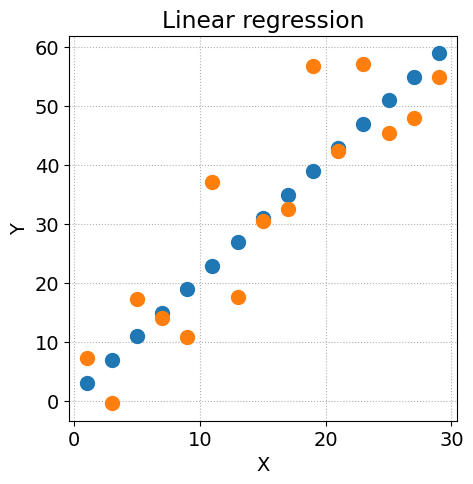

In [ ]:
# 이상적인 선형 관계(y = 2x + 1)를 가지는 데이터 (x, y)를 산점도로 그립니다.
# '.'는 마커 모양을 점(dot)으로, markersize=20은 점의 크기를 20으로 설정합니다.
plt.plot(x, y, ".", markersize = 20)
plt.plot(x, y_random, ".", markersize = 20)

# 그래프의 제목을 "Linear regression"으로 설정합니다.
plt.title("Linear regression")

# X축의 레이블을 "X"로 설정합니다.
plt.xlabel("X")

# Y축의 레이블을 "Y"로 설정합니다.
plt.ylabel("Y")
plt.show()

### 최소제곱 추정량 구하기
$\beta_1 = \frac{S_{xy}}{S_{xx}}$
$\beta_0 = \overline{y} - \beta_1\overline{x}$

In [38]:
# Sxy: x와 y_random의 편차 곱의 합을 계산하기 위해, 각 배열의 해당 편차 곱을 요소별로 계산합니다.
# (x - np.mean(x)): x 값에서 x의 평균을 뺀 편차 (Deviation of x)
# (y_random - np.mean(y_random)): y_random 값에서 y_random의 평균을 뺀 편차 (Deviation of y)

Sxy = (x - np.mean(x))*(y_random - np.mean(y_random))
Sxx = (x - np.mean(x))**2

# Sxy (Sum of cross-products of deviations): 교차 편차 제곱합
Sxy = Sxy.sum()
# Sxx (Sum of squares of deviations of x): x 편차 제곱합
Sxx = Sxx.sum()

print("제곱합 결과 = ")
print("Sxy = ", round(Sxy, 3))
print("Sxx = ", round(Sxx, 3))

# --------------- 선형 회귀 계수 계산 ---------------

# beta_1 (기울기, Slope) 계산: 회귀선의 기울기를 추정합니다.
beta_1 = Sxy/Sxx
# beta_0 (절편, Intercept) 계산: 회귀선의 Y절편을 추정합니다.
beta_0 = np.mean(y_random) - beta_1*np.mean(x)           

print("\n회귀 계수 = ")
print("beta_1 = {}".format(beta_1.round(3)))
print("beta_0 = {}".format(beta_0.round(3)))

제곱합 결과 = 
Sxy =  2171.238
Sxx =  1120.0

회귀 계수 = 
beta_1 = 1.939
beta_0 = 2.38


In [ ]:
# y_hat (추정된 y 값): 계산된 회귀 계수 (beta_1, beta_0)와 
# 독립 변수 x를 사용하여 회귀 방정식을 적용합니다.
# 이 식은 x의 각 값에 대해 회귀선 상의 예측된 y 값(y_hat)을 계산합니다.
y_hat = beta_1*x + beta_0

print(y_hat)

[ 4.31889107  8.19610119 12.07331131 15.95052143 19.82773155 23.70494167
 27.58215179 31.45936191 35.33657203 39.21378215 43.09099227 46.96820239
 50.84541251 54.72262263 58.59983275]


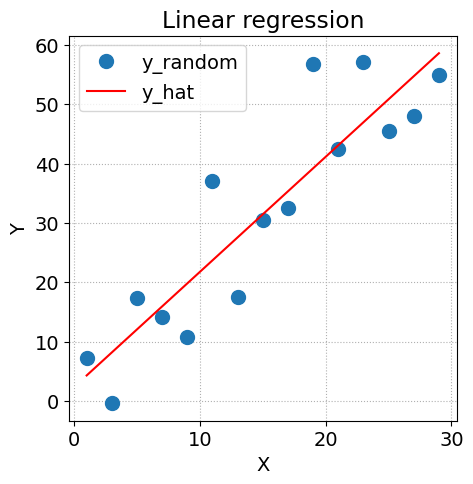

In [ ]:
# x: 독립 변수 (X축)
# y_random: 종속 변수 (Y축)
# ".": 마커 모양을 점(dot)으로 설정
# markersize=20: 점의 크기를 20으로 설정
# label="y_random": 범례(legend)에 표시될 레이블을 "y_random"으로 지정
plt.plot(x, y_random, ".", markersize = 20, label = "y_random")
plt.plot(x, y_hat, color = "r", label = "y_hat")
plt.title("Linear regression")
plt.xlabel("X")
plt.ylabel("Y")

# 각 플롯에 지정된 label을 사용하여 범례(Legend)를 표시합니다.
plt.legend()
plt.show()

## 2. Scikit-learn을 이용한 회귀분석

In [ ]:
# Scikit-learn의 선형 회귀 모델 임포트
from sklearn.linear_model import LinearRegression

### 단순 회귀 분석 (Simple linear regression)

In [ ]:
# seaborn 내장 'mpg' 데이터셋을 로드합니다.
mpg = sns.load_dataset("mpg") 
# 'mpg'부터 'weight'까지의 열(mpg, cylinders, displacement, horsepower, weight)만 선택합니다.
mpg = mpg.loc[:, "mpg": "weight"]
# 누락된 값(NaN)이 포함된 모든 행을 제거합니다 (대부분 'horsepower' 열에 NaN이 있음).
mpg.dropna(inplace = True)
# 데이터프레임의 상위 5개 행을 출력합니다
mpg.head()

,mpg,cylinders,displacement,horsepower,weight
0,18.0,8,307.0,130.0,3504
1,15.0,8,350.0,165.0,3693
2,18.0,8,318.0,150.0,3436
3,16.0,8,304.0,150.0,3433
4,17.0,8,302.0,140.0,3449


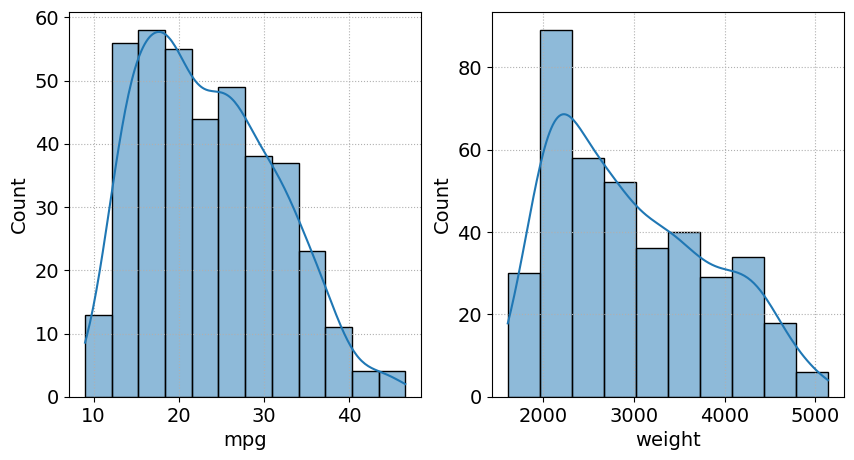

In [ ]:
# ----------------- 데이터 분포 시각화 -----------------
# 1행 2열의 서브플롯을 생성하고 전체 그림 크기를 (10x5)로 설정합니다.
fig, axs = plt.subplots(1, 2, figsize = (10, 5))
# 첫 번째 서브플롯에 'mpg'의 분포(히스토그램)와 확률 밀도 추정 곡선(kde)을 그립니다.
sns.histplot(mpg, x = "mpg", ax = axs[0], kde = True)
# 두 번째 서브플롯에 'weight'의 분포(히스토그램)와 확률 밀도 추정 곡선(kde)을 그립니다.
sns.histplot(mpg, x = "weight", ax = axs[1], kde = True)
plt.show()

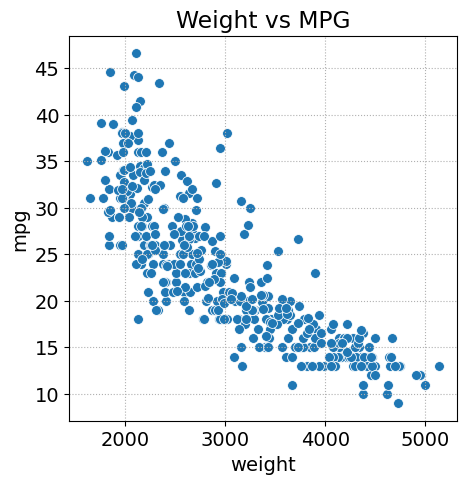

In [ ]:
# 'weight'와 'mpg' 사이의 관계를 산점도(Scatter Plot)로 시각화합니다.
# 점의 크기(s)를 50으로 설정합니다.
sns.scatterplot(mpg, x = "weight", y = "mpg", s = 50)
# 그래프 제목을 설정합니다.
plt.title("Weight vs MPG")
plt.show()

In [ ]:
# 독립 변수(X)로 'weight' 열을 선택합니다. (fit 메서드는 2차원 배열을 요구하므로 [[]] 사용)
x = mpg[["weight"]]
# 종속 변수(Y)로 'mpg' 열을 선택합니다.
y = mpg[["mpg"]]

In [ ]:
# 선형 회귀 모델 객체를 생성합니다
lr = LinearRegression()
# 모델을 훈련 데이터(x=weight, y=mpg)에 적합(fit)시킵니다.
lr.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# 회귀 모델의 기울기(beta_1)를 소수점 셋째 자리까지 반올림하여 출력합니다.
print("coeff = ", lr.coef_[0].round(3))
# 회귀 모델의 절편(beta_0)을 소수점 셋째 자리까지 반올림하여 출력합니다.
print("intercept = ", lr.intercept_.round(3))

coeff =  [-0.008]
intercept =  [46.217]


In [ ]:
# 결정 계수(R-squared)를 계산하고 출력합니다. (모델의 설명력, 1에 가까울수록 좋음)
print("R-squared = ", round(lr.score(x, y), 3))

R-squared =  0.693


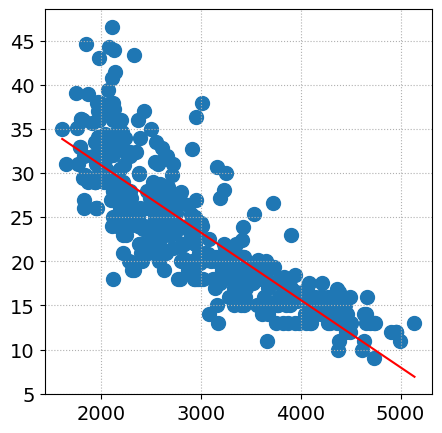

In [ ]:
# 회귀선을 그리기 위한 준비: x의 최솟값과 최댓값을 구합니다.
start = x.min()
stop = x.max()
# 최솟값부터 최댓값까지 10개의 균등 간격의 점으로 구성된 배열을 생성합니다. (회귀선 그리기용)
x_line = np.linspace(start, stop, 10)

# 원본 데이터를 산점도를 그립니다.
plt.scatter(x = "weight", y = "mpg", data=mpg, s = 100)
# 계산된 회귀 계수를 사용하여 최적의 회귀선 (빨간색)을 그립니다.
plt.plot(x_line, lr.coef_[0]*x_line + lr.intercept_, c = "r")
plt.show()

### 중회귀분석 (Multiple linear regression)

In [ ]:
# ----------------- 다중 회귀 분석: 'cylinders', 'displacement', 'horsepower', 'weight' vs 'mpg' -----------------
# 독립 변수(X)로 'cylinders'부터 'weight'까지의 여러 열을 선택합니다.
x = mpg.loc[:, 'cylinders':'weight']
# 종속 변수(Y)로 'mpg' 열을 선택합니다.
y = mpg[["mpg"]]

In [ ]:
# 새로운 선형 회귀 모델 객체를 생성합니다.
lr = LinearRegression()
# 다중 독립 변수(x)와 종속 변수(y)에 모델을 적합시킵니다.
lr.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# 각 독립 변수('cylinders', 'displacement', 'horsepower', 'weight')에 대한 계수 배열을 출력합니다.
print("coeff = ", lr.coef_.round(3))
# 회귀 모델의 절편(beta_0)을 출력합니다.
print("intercept = ", lr.intercept_.round(3))

coeff =  [[-0.393  0.    -0.043 -0.005]]
intercept =  [45.757]


In [ ]:
# 다중 회귀 모델의 결정 계수(R-squared)를 계산하고 출력합니다. 
# 이 값이 단순 회귀 모델의 R-squared보다 높으면 다중 변수가 더 잘 예측한다는 의미입니다.
print("R-squared = ", round(lr.score(x, y), 3))

R-squared =  0.708
